In [1]:
import os, random
import numpy as np
from glob import glob
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict

# reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [2]:
# Lymphoma
CLL_PATH = "/kaggle/input/datasets/andrewmvd/malignant-lymphoma-classification/CLL"
FL_PATH  = "/kaggle/input/datasets/andrewmvd/malignant-lymphoma-classification/FL"
MCL_PATH = "/kaggle/input/datasets/andrewmvd/malignant-lymphoma-classification/MCL"

# Leukemia + Healthy
ALL_PATH = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/train/train/all train/all train"
AML_PATH = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/train/train/aml train/aml train"
CLL_LEUK_PATH = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/train/train/cll train/cll train"
CML_PATH = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/train/train/cml/cml"
HEALTHY_PATH = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/train/train/h train/h train"

# Myeloma
MYELOMA_TRAIN = "//kaggle/input/datasets/sbilab/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/train/train/train/x"
MYELOMA_VAL   = "/kaggle/input/datasets/sbilab/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/validation/validation/x"

# External TEST datasets (you provide)
TEST_ALL = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/test/test/ALL TEST-20230225T082325Z-001/ALL TEST"
TEST_AML = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/test/test/AML TEST-20230225T082630Z-001/AML TEST"
TEST_CLL = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/test/test/CLL TEST-20230225T082851Z-001/CLL TEST"
TEST_CML = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/test/test/CML TEST-20230225T083148Z-001/CML TEST"
TEST_MYELOMA = "/kaggle/input/datasets/sbilab/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/test/x"
TEST_HEALTHY = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/test/test/H TEST-20230225T083612Z-001/H TEST"

In [3]:
def get_imgs(path):
    return (
        glob(path + "/**/*.jpg", recursive=True) +
        glob(path + "/**/*.png", recursive=True) +
        glob(path + "/**/*.tif", recursive=True) +
        glob(path + "/**/*.bmp", recursive=True)
    )

leukemia_imgs = get_imgs(ALL_PATH) + get_imgs(AML_PATH) + get_imgs(CLL_LEUK_PATH) + get_imgs(CML_PATH)
healthy_imgs  = get_imgs(HEALTHY_PATH)
lymphoma_imgs = get_imgs(CLL_PATH) + get_imgs(FL_PATH) + get_imgs(MCL_PATH)

# 🔥 myeloma = train + val
myel_train = get_imgs(MYELOMA_TRAIN) + get_imgs(MYELOMA_VAL)

print(len(leukemia_imgs), len(lymphoma_imgs), len(myel_train), len(healthy_imgs))

12000 374 498 3000


In [4]:
def get_patient_id(path):
    return os.path.basename(path).split("_")[0]

def patient_split(imgs, split=0.8):
    groups = defaultdict(list)
    for img in imgs:
        groups[get_patient_id(img)].append(img)

    pids = list(groups.keys())
    random.shuffle(pids)

    cut = int(len(pids) * split)
    train_ids, test_ids = pids[:cut], pids[cut:]

    train, test = [], []
    for pid in train_ids:
        train.extend(groups[pid])
    for pid in test_ids:
        test.extend(groups[pid])

    return train, test

lymph_train, lymph_test = patient_split(lymphoma_imgs)

In [5]:
leuk_train = random.sample(leukemia_imgs, 3000)
health_train = random.sample(healthy_imgs, 2000)

lymph_train = lymph_train * 4
myel_train  = myel_train * 2

In [6]:
train_data = []

for img in leuk_train: train_data.append((img,0))
for img in lymph_train: train_data.append((img,1))
for img in myel_train: train_data.append((img,2))
for img in health_train: train_data.append((img,3))

random.shuffle(train_data)

In [7]:
val_data = []

# 🔴 Leukemia subtypes → ALL map to class 0
for img in get_imgs(TEST_ALL):
    val_data.append((img,0))

for img in get_imgs(TEST_AML):
    val_data.append((img,0))

for img in get_imgs(TEST_CLL):
    val_data.append((img,0))

for img in get_imgs(TEST_CML):
    val_data.append((img,0))

# 🟡 Myeloma
for img in get_imgs(TEST_MYELOMA):
    val_data.append((img,2))

# 🟢 Healthy
for img in get_imgs(TEST_HEALTHY):
    val_data.append((img,3))

In [8]:
test_data = []
test_subtypes = []

# Leukemia subtypes → label 0
for img in get_imgs(TEST_ALL):
    test_data.append((img, 0))
    test_subtypes.append("ALL")

for img in get_imgs(TEST_AML):
    test_data.append((img, 0))
    test_subtypes.append("AML")

for img in get_imgs(TEST_CLL):
    test_data.append((img, 0))
    test_subtypes.append("CLL")

for img in get_imgs(TEST_CML):
    test_data.append((img, 0))
    test_subtypes.append("CML")

# Other classes
for img in get_imgs(TEST_MYELOMA):
    test_data.append((img, 2))
    test_subtypes.append("MYELOMA")

for img in get_imgs(TEST_HEALTHY):
    test_data.append((img, 3))
    test_subtypes.append("HEALTHY")

# Lymphoma
for img in lymph_test:
    test_data.append((img, 1))
    test_subtypes.append("LYMPHOMA")

In [9]:
class BloodDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, label = self.data[idx]
        try:
            img = Image.open(path).convert("RGB")
        except:
            return self.__getitem__((idx+1) % len(self.data))

        if self.transform:
            img = self.transform(img)

        return img, label

In [10]:
print(len(get_imgs(TEST_ALL)))
print(len(get_imgs(TEST_AML)))
print(len(get_imgs(TEST_CLL)))
print(len(get_imgs(TEST_CML)))

1000
1000
1000
1000


In [11]:
train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(40),
    transforms.ColorJitter(0.6,0.6,0.6),
    transforms.RandomResizedCrop(224, scale=(0.5,1.0)),
    transforms.GaussianBlur(5),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [12]:
train_loader = DataLoader(BloodDataset(train_data, train_tfms),
                          batch_size=32, shuffle=True)

val_loader = DataLoader(BloodDataset(val_data, val_tfms),
                        batch_size=32, shuffle=False)

test_loader = DataLoader(BloodDataset(test_data, val_tfms),
                         batch_size=32, shuffle=False)

In [13]:
model = models.efficientnet_b0(weights="IMAGENET1K_V1")
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 4)

for p in model.features.parameters():
    p.requires_grad = False

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 142MB/s] 


In [14]:
weights = torch.tensor([1.0, 4.0, 1.8, 1.0]).to(device)

criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

In [15]:
epochs = 10
best_val_loss = float("inf")
counter = 0

for epoch in range(epochs):

    # TRAIN
    model.train()
    train_loss, correct, total = 0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Train"):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} Val"):
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    scheduler.step()

    # UNFREEZE
    if epoch == 3:
        print("🔓 Unfreezing backbone")
        for p in model.features.parameters():
            p.requires_grad = True
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    # EARLY STOP
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= 3:
            print("⛔ Early stopping")
            break

Epoch 1 Val: 100%|██████████| 165/165 [12:21<00:00,  4.49s/it]



Epoch 1
Train Loss: 0.9880 | Train Acc: 0.7380
Val   Loss: 0.9268 | Val   Acc: 0.9341


Epoch 2 Val: 100%|██████████| 165/165 [12:51<00:00,  4.67s/it]



Epoch 2
Train Loss: 0.6194 | Train Acc: 0.9059
Val   Loss: 0.8173 | Val   Acc: 0.9665


Epoch 3 Val: 100%|██████████| 165/165 [12:17<00:00,  4.47s/it]


...


Epoch 8
Train Loss: 0.4455 | Train Acc: 0.9844
Val   Loss: 0.6586 | Val   Acc: 0.9991


Epoch 9 Val: 100%|██████████| 165/165 [12:44<00:00,  4.64s/it]



Epoch 9
Train Loss: 0.4384 | Train Acc: 0.9876
Val   Loss: 0.6552 | Val   Acc: 0.9987


Epoch 10 Val: 100%|██████████| 165/165 [12:31<00:00,  4.55s/it]


Epoch 10
Train Loss: 0.4364 | Train Acc: 0.9890
Val   Loss: 0.6530 | Val   Acc: 0.9987


In [16]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("FINAL TEST ACCURACY:", np.mean(np.array(all_preds)==np.array(all_labels)))

FINAL TEST ACCURACY: 0.9979446935724963


In [17]:
from collections import defaultdict

subtype_correct = defaultdict(int)
subtype_total = defaultdict(int)

for i in range(len(all_preds)):
    subtype = test_subtypes[i]

    if all_preds[i] == all_labels[i]:
        subtype_correct[subtype] += 1

    subtype_total[subtype] += 1

print("\n🔬 Subtype-wise Accuracy:")
for k in subtype_total:
    acc = subtype_correct[k] / subtype_total[k]
    print(f"{k}: {acc:.4f}")


🔬 Subtype-wise Accuracy:
ALL: 0.9980
AML: 0.9990
CLL: 0.9990
CML: 1.0000
MYELOMA: 1.0000
HEALTHY: 0.9970
LYMPHOMA: 0.9467


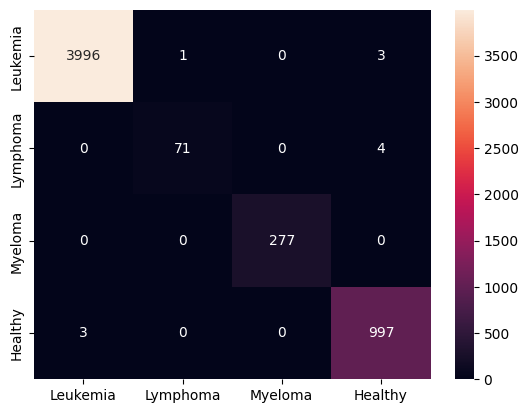

              precision    recall  f1-score   support

           0     0.9992    0.9990    0.9991      4000
           1     0.9861    0.9467    0.9660        75
           2     1.0000    1.0000    1.0000       277
           3     0.9930    0.9970    0.9950      1000

    accuracy                         0.9979      5352
   macro avg     0.9946    0.9857    0.9900      5352
weighted avg     0.9979    0.9979    0.9979      5352



In [18]:
labels = ["Leukemia","Lymphoma","Myeloma","Healthy"]

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=labels,
            yticklabels=labels)
plt.show()

print(classification_report(all_labels, all_preds, digits=4))